# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук - заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm - если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста - не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [ ]:
pre_reg_thoughts = """
1. Переобучение для меня - это когда нейронка превращается в зубрилу. Она идеально запоминает конкретные картинки из тренировочного набора (вплоть до шумов и случайных пятен), 
но когда видит новую цифру, написанную чуть иначе, - теряется. Это как выучить ответы к тесту, не понимая самой темы.

2. Даже если «всё обучается», это не значит, что оно обучается правильно. Регуляризация нужна, чтобы модель не искала легких путей и не полагалась на случайные признаки.

3. Если объяснять одногруппнику на пальцах:
   - L2-штраф (Weight Decay): Это «налог на сложность». Мы бьем модель по рукам за слишком большие веса, заставляя её распределять важность между всеми пикселями понемногу, а не зацикливаться на паре-тройке «любимых».
   - Dropout: Это «метод слепого случая». Мы на каждой итерации выключаем случайные нейроны. Это заставляет остальные части сети брать на себя ответственность и дублировать функции друг друга - система становится живучей.
   - BatchNorm: Это «уравниловка». Он берет выходы слоев и приводит их к общему знаменателю (среднему и дисперсии). В итоге слоям не нужно постоянно подстраиваться под резкие скачки данных от предыдущих слоев, и обучение идет в разы быстрее и спокойнее.
"""
print(pre_reg_thoughts)

## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 17
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 17


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [2]:
batch_size = 64  #TODO: Попробуйте несколько значений. Запишите, как меняется время эпохи и шумность loss-кривой в зависимости от размера батча

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 240kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.40MB/s]

train size = 60000
test size  = 10000
batch_size = 64


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


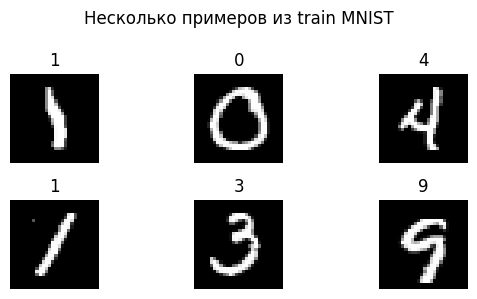

In [3]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» - это просто ваши наблюдения.

In [ ]:
data_impression = """Визуально цифры в выборке достаточно контрастные и узнаваемые, однако уже на первых шести примерах заметна вариативность почерка.
Например, первая "1" имеет характерный изгиб, а вторая - сильный наклон, что может запутать простую модель.
"4" и "9" имеют схожую структуру нижней части, а у "3" нижний крючок прорисован не полностью, что при низком разрешении может быть принято за "8" или "2". 
Такие нюансы подтверждают, что данные не идеально однородны, и регуляризация будет полезна для того, чтобы сеть не запоминала конкретные наклоны линий, а искала общие контуры цифр"""
print(data_impression)

## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** - без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** - тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** - тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [4]:
class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            # TODO: размеры слоёв (256, 128) выбраны произвольно.
            # Подберите свои значения и обоснуйте в отчёте:
            # достаточно ли этого, чтобы модель вообще могла переобучиться?
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: Dropout стоит ПОСЛЕ активации, это стандартная практика.
        # Попробуйте поставить его ДО активации и опишите, изменилось ли что-то.
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, что физически происходит здесь во время train?
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, почему здесь тот же p, а не другой?
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: BatchNorm1d стоит ДО активации - это один из двух стандартных вариантов.
        # Попробуйте переставить его после ReLU. Есть ли разница в сходимости?
        # TODO: объясните в отчёте: что именно нормализует BatchNorm1d(256)?
        # Что такое «батч» в данном контексте, строки или столбцы матрицы?
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): B

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` - один проход по train;
- `evaluate` - оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование - делайте это здесь и прокомментируйте в отчёте.


In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [7]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    # создаём модель нужного класса
    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` - BaseMLP, `weight_decay=0`.  
2. `Base / L2` - BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` - DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` - BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [8]:
# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.2260, train_acc=0.9312, test_loss=0.1014, test_acc=0.9676
Эпоха 2/8 | train_loss=0.0933, train_acc=0.9713, test_loss=0.1043, test_acc=0.9665
Эпоха 3/8 | train_loss=0.0669, train_acc=0.9787, test_loss=0.0784, test_acc=0.9769
Эпоха 4/8 | train_loss=0.0518, train_acc=0.9831, test_loss=0.0804, test_acc=0.9759
Эпоха 5/8 | train_loss=0.0407, train_acc=0.9865, test_loss=0.0803, test_acc=0.9762
Эпоха 6/8 | train_loss=0.0325, train_acc=0.9892, test_loss=0.0818, test_acc=0.9753
Эпоха 7/8 | train_loss=0.0297, train_acc=0.9903, test_loss=0.0770, test_acc=0.9805
Эпоха 8/8 | train_loss=0.0243, train_acc=0.9917, test_loss=0.0667, test_acc=0.9831


In [9]:
# 2. Базовая модель с L2 (weight decay)
# TODO: weight_decay=1e-4 - почему именно это значение?
# Попробуйте 1e-2 и 1e-6. Запишите test_acc для каждого случая и опишите, где слишком много L2.
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-4)",
    weight_decay=1e-4,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / L2 (wd=1e-4) ===
Эпоха 1/8 | train_loss=0.2302, train_acc=0.9303, test_loss=0.1089, test_acc=0.9653
Эпоха 2/8 | train_loss=0.0922, train_acc=0.9722, test_loss=0.0971, test_acc=0.9701
Эпоха 3/8 | train_loss=0.0681, train_acc=0.9784, test_loss=0.0885, test_acc=0.9724
Эпоха 4/8 | train_loss=0.0520, train_acc=0.9837, test_loss=0.0824, test_acc=0.9738
Эпоха 5/8 | train_loss=0.0441, train_acc=0.9859, test_loss=0.0776, test_acc=0.9773
Эпоха 6/8 | train_loss=0.0374, train_acc=0.9875, test_loss=0.0817, test_acc=0.9774
Эпоха 7/8 | train_loss=0.0330, train_acc=0.9893, test_loss=0.0719, test_acc=0.9790
Эпоха 8/8 | train_loss=0.0305, train_acc=0.9900, test_loss=0.0756, test_acc=0.9793


In [10]:
# 3. Модель с Dropout
# TODO: dropout_p=0.5 - агрессивное значение. Попробуйте p=0.2 и p=0.7.
# При каком p модель обучается слишком медленно, а при каком почти не регуляризует?
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.5",
    dropout_p=0.5,
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Dropout p=0.5 ===
Эпоха 1/8 | train_loss=0.4183, train_acc=0.8730, test_loss=0.1497, test_acc=0.9544
Эпоха 2/8 | train_loss=0.2314, train_acc=0.9334, test_loss=0.1202, test_acc=0.9655
Эпоха 3/8 | train_loss=0.1957, train_acc=0.9429, test_loss=0.0996, test_acc=0.9695
Эпоха 4/8 | train_loss=0.1757, train_acc=0.9480, test_loss=0.0945, test_acc=0.9724
Эпоха 5/8 | train_loss=0.1600, train_acc=0.9527, test_loss=0.0847, test_acc=0.9763
Эпоха 6/8 | train_loss=0.1515, train_acc=0.9553, test_loss=0.0851, test_acc=0.9740
Эпоха 7/8 | train_loss=0.1468, train_acc=0.9579, test_loss=0.0837, test_acc=0.9748
Эпоха 8/8 | train_loss=0.1348, train_acc=0.9605, test_loss=0.0857, test_acc=0.9747


In [11]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.2064, train_acc=0.9430, test_loss=0.1001, test_acc=0.9686
Эпоха 2/8 | train_loss=0.0849, train_acc=0.9740, test_loss=0.0702, test_acc=0.9777
Эпоха 3/8 | train_loss=0.0563, train_acc=0.9820, test_loss=0.0660, test_acc=0.9788
Эпоха 4/8 | train_loss=0.0448, train_acc=0.9853, test_loss=0.0666, test_acc=0.9783
Эпоха 5/8 | train_loss=0.0353, train_acc=0.9888, test_loss=0.0659, test_acc=0.9783
Эпоха 6/8 | train_loss=0.0316, train_acc=0.9900, test_loss=0.0618, test_acc=0.9803
Эпоха 7/8 | train_loss=0.0269, train_acc=0.9910, test_loss=0.0597, test_acc=0.9813
Эпоха 8/8 | train_loss=0.0209, train_acc=0.9932, test_loss=0.0673, test_acc=0.9797


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов: 
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


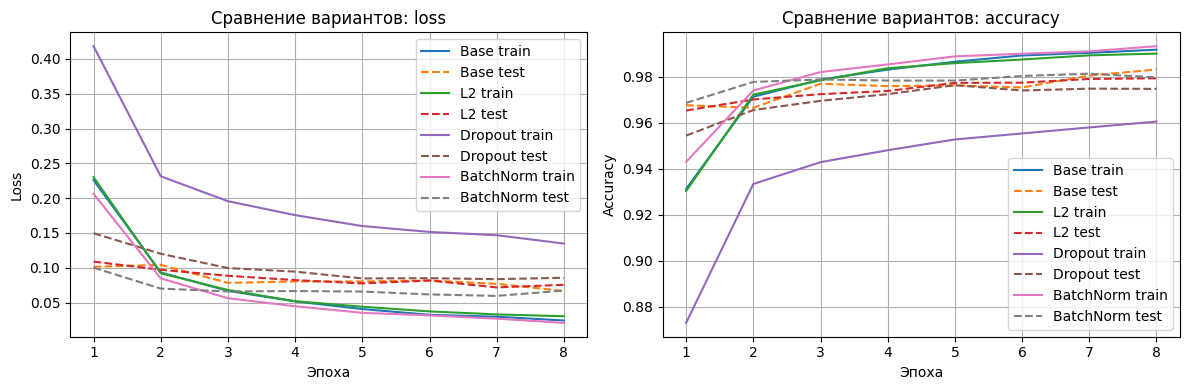

In [12]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) - это тоже часть обучения.


In [ ]:
analysis_comment = """Глядя на графики, сразу бросается в глаза поведение базовой модели (Base): к 8-й эпохе разрыв между train и test стал довольно ощутимым. Если на трейне точность дошла до 0.9917,
то на тесте она замерла на 0.9831, а кривая лосса на тесте начала понемногу "дребезжать", что явно намекает на старт переобучения.

Добавление L2 (wd=1e-4) немного притормозило обучение на трейне (0.9900), но при этом тестовый лосс стал выглядеть чуть стабильнее, хотя итоговая точность на тесте оказалась даже чуть ниже базовой (0.9793).
Возможно, для такой простой задачи как MNIST этот коэффициент великоват.

Dropout (p=0.5) повел себя агрессивно: на графике лосса видно, как сильно он взлетел в начале (почти 0.42 против 0.2 у остальных). Обучение идет заметно медленнее, точность на трейне самая низкая (0.9605),
зато разрыва с тестом практически нет - модель вообще не может "зазубрить" данные.

BatchNorm же оказался фаворитом по скорости: уже на 2-й эпохе он обошел всех по точности, а его кривые выглядят самыми плавными. На 8-й эпохе он показал отличный баланс: 0.9932 на трейне и стабильные 0.9797 на тесте.

Если выбирать одну технику, я бы остановился на BatchNorm.
Он не только стабилизирует процесс, но и позволяет нейронке выходить на высокие показатели гораздо быстрее базовой архитектуры, не требуя при этом такой жесткой "пытки" нейронов, как Dropout"""
print(analysis_comment)

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm - именно на примере **ваших** экспериментов, а не абстрактной теории.


In [ ]:
final_summary = """В ходе выполнения работы я пришел к выводу, что для задачи классификации MNIST "золотой серединой" является использование архитектуры с BatchNorm и умеренным Learning Rate (1e-3). 
Эксперименты показали, что BatchNorm не только ускоряет сходимость, позволяя достичь высокой точности уже ко второй эпохе, но и делает процесс обучения более предсказуемым. 
Мои ожидания относительно Dropout подтвердились лишь частично: при значении p=0.5 он слишком сильно замедляет обучение, хотя и полностью исключает переобучение, поэтому в будущих проектах я буду пробовать более мягкие значения (0.2–0.3).
L2-регуляризация показала себя как полезный, но тонкий инструмент, требующий тщательного подбора коэффициента, чтобы не "задушить" обучение. 
Главный урок этой лабы - регуляризация не просто улучшает метрики, она меняет саму динамику обучения, и теперь при разработке сложных сервисов (например, для ВКР) я буду в первую очередь внедрять слои нормализации для стабилизации градиентов"""
print(final_summary)